# Surface area and volume change approximation of the lower tongue of the Great Aletsch Glacier using Sentinel-2 and DEM Data

This project analyzes changes in the lower tongue of the Great Aletsch Glacier in Switzerland. The study is based on Sentinel-2 satellite images downloaded from the Copernicus Browser for three late-summer dates:

1. 29th of August 2015
2. 27th of August 2020
3. 26th of August 2025

The images were downloaded for the same area of interest and with the same spatial resolution, so the glacier masks and calculated areas can be compared between dates.

The main part of the project focuses on estimating glacier surface area from Sentinel-2 multispectral bands. The glacier tounge is segmented using spectral indices, mainly NDSI and also the NDVI to reduce confusion with vegetation and surrounding terrain. The calculated glacier masks are then used to compare the surface area of the selected glacier tongue in 2015, 2020 and 2025.

To extend the analysis, DEM-derived elevation-change data is also used. The elevation-change raster was downloaded as a `dhdt` GeoTIFF tile covering the Aletsch region:

`N46E008_2015-01-01_2020-01-01_dhdt.tif`

This project represents the average annual elevation change rate for the period from 2015-01-01 to 2020-01-01. It was downloaded as a 1° × 1° tile for the area around 46°N, 8°E, which contains the Great Aletsch Glacier. The raster is used to estimate total elevation change over the 2015-2020 period and then approximate volume change by multiplying elevation change by pixel area.

Main goals:

1. Load Sentinel-2 bands for 2015, 2020 and 2025.
2. Visualize true color, false color, histograms and spectral indices.
3. Segment the lower glacier tongue using image processing methods.
4. Calculate glacier surface area in km2 and compare the dates.
5. Use DEM-derived elevation change to estimate approximate volume change for 2015-2020.

Study area: lower tongue of the Great Aletsch Glacier, Switzerland.

## 1. Imports and project paths

The notebook follows such a folder structure:

```text
project/
├── data/
│   ├── 2015_bands/
│   ├── 2020_bands/
│   ├── 2025_bands/
│   └── DEM/
│       └── N46E008_2015-01-01_2020-01-01_dhdt.tif
├── outputs/
└── main.ipynb
```

The `*_bands` folders are used for calculations. The 8-bit folders are useful only for visuals.

In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import reproject, Resampling

from skimage import morphology, measure
from sklearn.cluster import MiniBatchKMeans


PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RASTER_DIR = OUTPUT_DIR / "rasters"
DEM_PATH = DATA_DIR / "DEM" / "N46E008_2015-01-01_2020-01-01_dhdt.tif"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RASTER_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2015, 2020, 2025]
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]

NDSI_THRESHOLD = 0.25
NDVI_MAX = 0.25
MIN_OBJECT_SIZE = 300
KEEP_LARGEST_COMPONENT = True

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)
print("DEM file:", DEM_PATH)

Project directory: c:\Users\patry\OneDrive\Pulpit\UNI\sem4\ImageProcessing\project
Data directory: c:\Users\patry\OneDrive\Pulpit\UNI\sem4\ImageProcessing\project\data
Output directory: c:\Users\patry\OneDrive\Pulpit\UNI\sem4\ImageProcessing\project\outputs
DEM file: c:\Users\patry\OneDrive\Pulpit\UNI\sem4\ImageProcessing\project\data\DEM\N46E008_2015-01-01_2020-01-01_dhdt.tif


## 2. Helper functions

In [32]:
def find_band_path(year, band):
    folder = DATA_DIR / f"{year}_bands"
    matches = sorted(folder.glob(f"*_{band}_*.tif*"))

    return matches[0]


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, profile


def read_year_bands(year):
    data = {}
    profiles = {}
    for band in BANDS:
        path = find_band_path(year, band)
        arr, profile = read_raster(path)
        data[band] = arr
        profiles[band] = profile

    return data, profiles


def safe_index(a, b):
    return (a - b) / (a + b + 1e-6)


def percentile_stretch(arr, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(arr, (p_low, p_high))
    if hi == lo:
        return np.zeros_like(arr, dtype=np.float32)
    out = (arr - lo) / (hi - lo)

    return np.clip(out, 0, 1)


def make_rgb(data, bands=("B04", "B03", "B02")):
    return np.dstack([percentile_stretch(data[b]) for b in bands])


def clean_mask(mask, min_size=300, keep_largest=True):
    mask = np.asarray(mask, dtype=bool)
    mask = morphology.remove_small_objects(mask, max_size=min_size)
    mask = morphology.remove_small_holes(mask, max_size=min_size)

    if keep_largest:
        labels = measure.label(mask)
        props = measure.regionprops(labels)
        if props:
            largest = max(props, key=lambda p: p.area)
            mask = labels == largest.label

    return mask


def pixel_area_from_profile(profile):
    transform = profile["transform"]

    return abs(transform.a * transform.e)


def save_mask(mask, reference_profile, out_path):
    profile = reference_profile.copy()
    profile.update(dtype="uint8", count=1, nodata=0, compress="lzw")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(mask.astype(np.uint8), 1)


def save_float_raster(arr, reference_profile, out_path, nodata=-9999.0):
    profile = reference_profile.copy()
    profile.update(dtype="float32", count=1, nodata=nodata, compress="lzw")
    out = arr.astype(np.float32).copy()
    out[~np.isfinite(out)] = nodata
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(out, 1)

## 3. Loading the Sentinel-2 raw bands and printing metadata

The analysis uses six Sentinel-2 bands:

- `B02` - blue
- `B03` - green
- `B04` - red
- `B08` - near infrared
- `B11` - short-wave infrared
- `B12` - short-wave infrared

The main index is NDSI:

```text
NDSI = (B03 - B11) / (B03 + B11)
```

NDVI is used to reduce the influence of vegetation:

```text
NDVI = (B08 - B04) / (B08 + B04)
```

In [33]:
s2_data = {}
s2_profiles = {}

for year in YEARS:
    s2_data[year], s2_profiles[year] = read_year_bands(year)

ref_profile = s2_profiles[YEARS[0]]["B03"]
ref_shape = s2_data[YEARS[0]]["B03"].shape
ref_transform = ref_profile["transform"]
ref_crs = ref_profile["crs"]
ref_pixel_area = pixel_area_from_profile(ref_profile)

print("Reference shape:", ref_shape)
print("Reference CRS:", ref_crs)

print("Reference transform:")
print(ref_transform)

print("Pixel area [m2]:", ref_pixel_area)

for year in YEARS:
    print(f"\n{year}")
    profile = s2_profiles[year]["B03"]

    print("Shape:", (profile["height"], profile["width"]))
    print("CRS:", profile["crs"])

    print("Transform:")
    print(profile["transform"])

    print("Bounds:", rasterio.transform.array_bounds(profile["height"], profile["width"], profile["transform"]))

Reference shape: (1057, 670)
Reference CRS: EPSG:32632
Reference transform:
| 10.01, 0.00, 424050.44|
| 0.00,-10.00, 5148794.46|
| 0.00, 0.00, 1.00|
Pixel area [m2]: 100.03245466845473

2015
Shape: (1057, 670)
CRS: EPSG:32632
Transform:
| 10.01, 0.00, 424050.44|
| 0.00,-10.00, 5148794.46|
| 0.00, 0.00, 1.00|
Bounds: (424050.441752, 5138227.896334, 430754.796943, 5148794.458226)

2020
Shape: (1057, 670)
CRS: EPSG:32632
Transform:
| 10.01, 0.00, 424050.44|
| 0.00,-10.00, 5148794.46|
| 0.00, 0.00, 1.00|
Bounds: (424050.441752, 5138227.896334, 430754.796943, 5148794.458226)

2025
Shape: (1057, 670)
CRS: EPSG:32632
Transform:
| 10.01, 0.00, 424050.44|
| 0.00,-10.00, 5148794.46|
| 0.00, 0.00, 1.00|
Bounds: (424050.441752, 5138227.896334, 430754.796943, 5148794.458226)


In [34]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np

gif_frames = []

animation_years = list(YEARS) + list(YEARS)[-2:0:-1]

for year in animation_years:
    rgb = make_rgb(s2_data[year], ("B04", "B03", "B02"))

    rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    img = Image.fromarray(rgb_uint8)

    draw = ImageDraw.Draw(img)

    text = str(year)

    try:
        font = ImageFont.truetype("arial.ttf", 48)
    except:
        font = ImageFont.load_default()

    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    margin = 28
    x = img.width - text_width - margin
    y = img.height - text_height - margin

    draw.text(
        (x, y),
        text,
        fill=(255, 255, 255),
        font=font
    )

    gif_frames.append(img)

gif_path = FIG_DIR / "glacier_years.gif"

gif_frames[0].save(
    gif_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=1200,
    loop=0
)

gif_path

WindowsPath('c:/Users/patry/OneDrive/Pulpit/UNI/sem4/ImageProcessing/project/outputs/figures/glacier_years.gif')

## 4. True color and false color visualizations

True color uses `B04, B03, B02` and is close to a natural image. False color uses `B08, B04, B03`, so that the vegetation and ice/rock differences are easier to spot

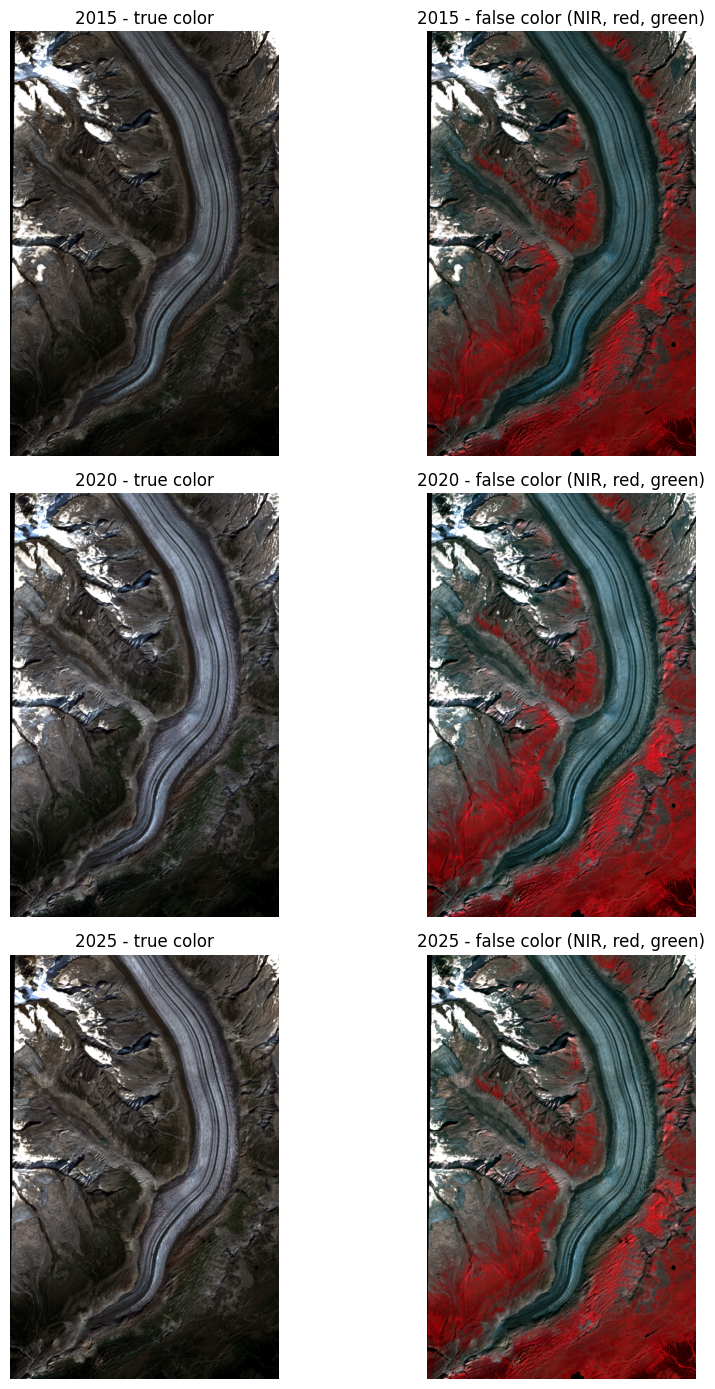

In [35]:
fig, axes = plt.subplots(len(YEARS), 2, figsize=(10, 14))

for i, year in enumerate(YEARS):
    true_color = make_rgb(s2_data[year], ("B04", "B03", "B02"))
    false_color = make_rgb(s2_data[year], ("B08", "B04", "B03"))

    axes[i, 0].imshow(true_color)
    axes[i, 0].set_title(f"{year} - true color")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(false_color)
    axes[i, 1].set_title(f"{year} - false color (NIR, red, green)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_true_false_color.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Histograms of selected bands

Histograms show the distribution of pixel values in selected bands. They are useful for checking whether the downloaded images have similar value ranges and we can also choose segmentation thresholds.

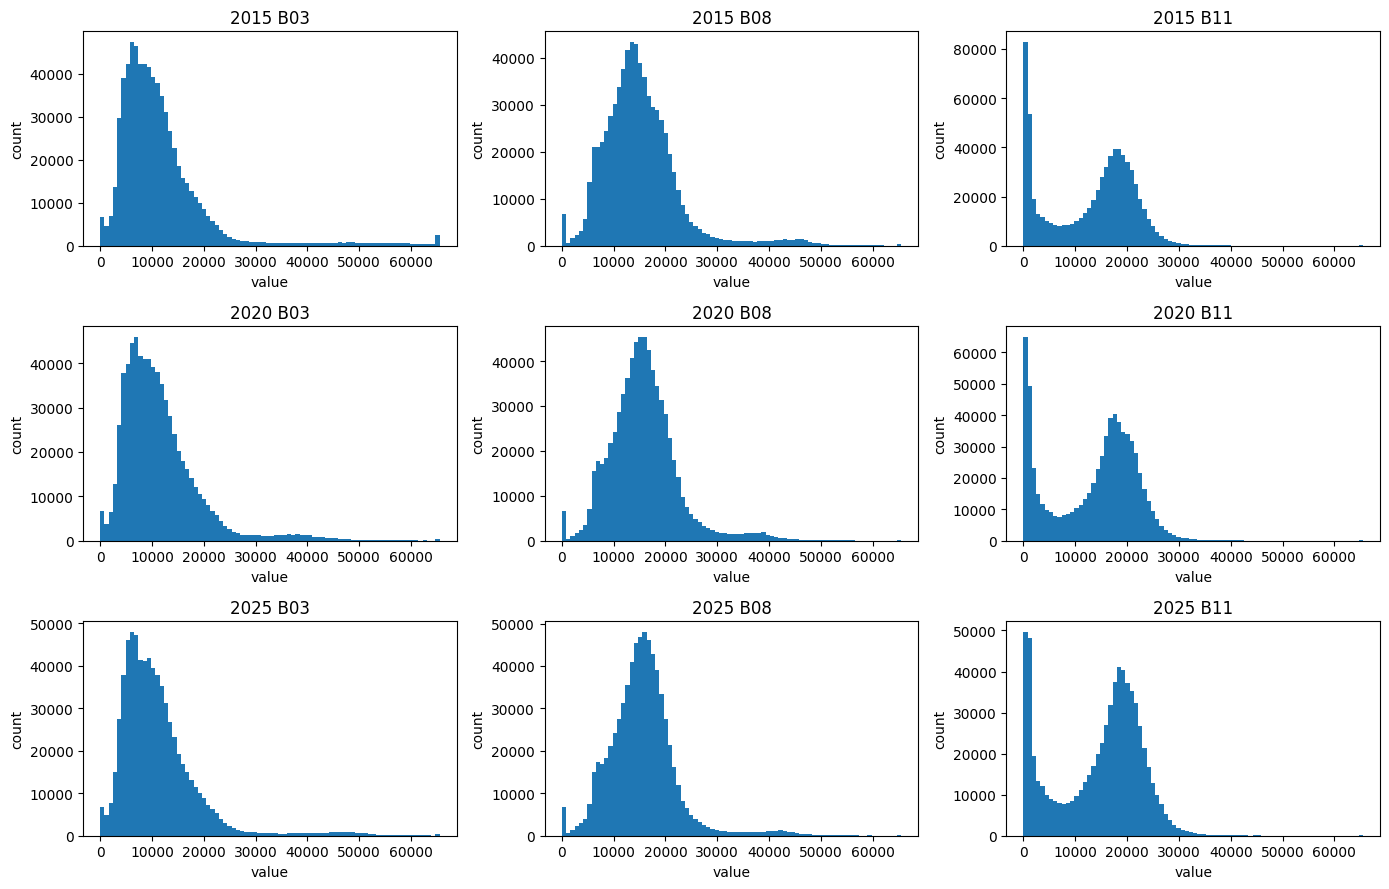

In [36]:
selected_bands = ["B03", "B08", "B11"]

fig, axes = plt.subplots(len(YEARS), len(selected_bands), figsize=(14, 9))

for i, year in enumerate(YEARS):
    for j, band in enumerate(selected_bands):
        arr = s2_data[year][band]
        valid = arr[np.isfinite(arr)]
        axes[i, j].hist(valid.ravel(), bins=80)
        axes[i, j].set_title(f"{year} {band}")
        axes[i, j].set_xlabel("value")
        axes[i, j].set_ylabel("count")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_band_histograms.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Calculate NDSI and NDVI

NDSI is high for snow and clean ice because they are bright in the green band and darker in SWIR. NDVI is higher for vegetation, so it helps remove green slopes and forested areas from the glacier mask.

In [37]:
indices = {}

for year in YEARS:
    data = s2_data[year]
    ndsi = safe_index(data["B03"], data["B11"])
    ndvi = safe_index(data["B08"], data["B04"])
    indices[year] = {
        "NDSI": ndsi,
        "NDVI": ndvi
    }

    print(f"\n{year}")
    print("NDSI percentiles:", np.nanpercentile(ndsi, [1, 5, 50, 95, 99]))
    print("NDVI percentiles:", np.nanpercentile(ndvi, [1, 5, 50, 95, 99]))


2015
NDSI percentiles: [-0.61524278 -0.5672869  -0.24381356  0.952519    0.96674154]
NDVI percentiles: [-0.2221359  -0.17155555  0.03849762  0.71805753  0.81448366]

2020
NDSI percentiles: [-0.5965978  -0.55542883 -0.25040203  0.93035978  0.94879454]
NDVI percentiles: [-0.13823885 -0.11603406  0.05243556  0.7203087   0.8143657 ]

2025
NDSI percentiles: [-0.62845914 -0.57851791 -0.27892302  0.92559636  0.94716299]
NDVI percentiles: [-0.13950778 -0.11231679  0.06445716  0.69791597  0.81751011]


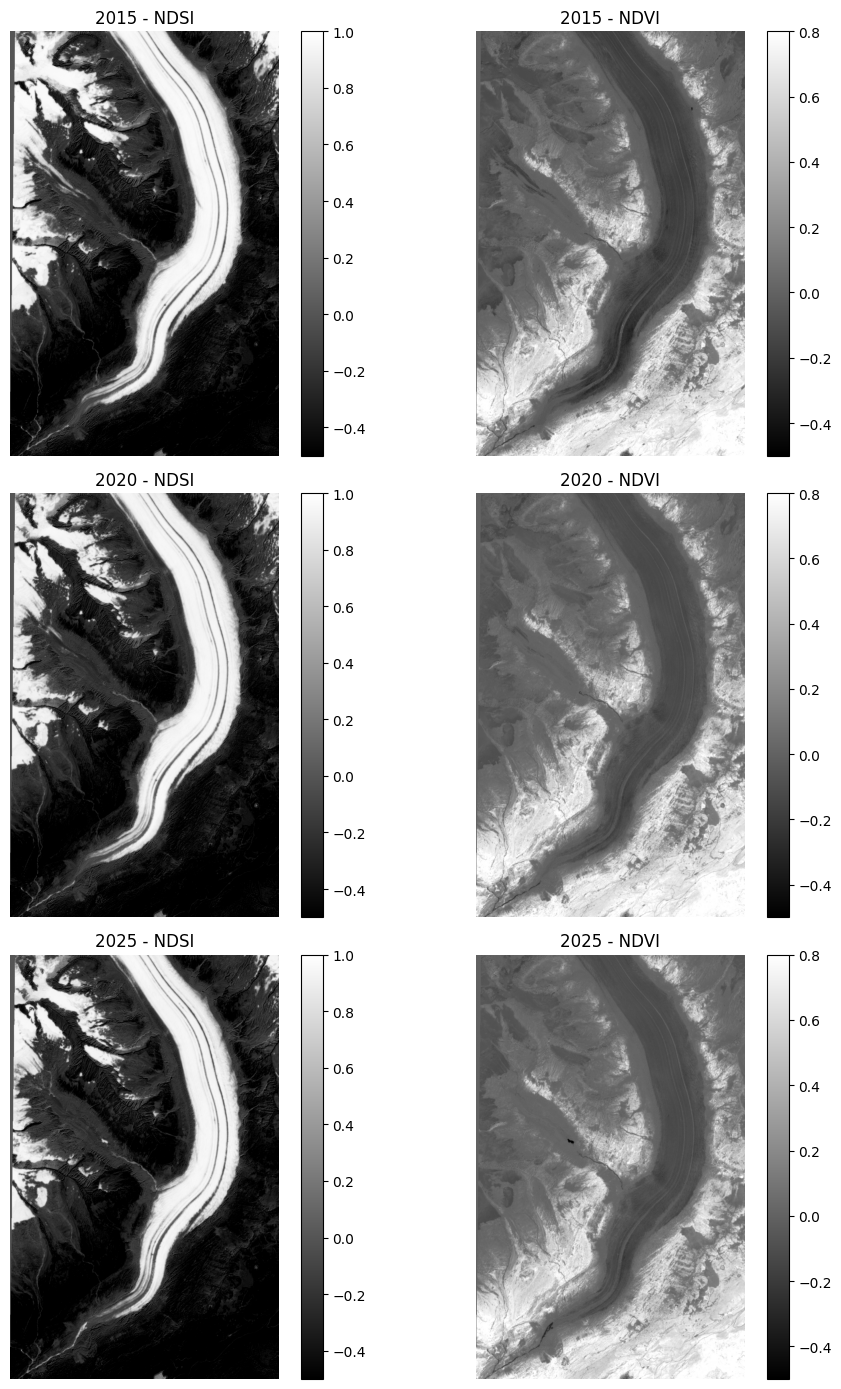

In [38]:
fig, axes = plt.subplots(len(YEARS), 2, figsize=(11, 14))

for i, year in enumerate(YEARS):
    im0 = axes[i, 0].imshow(indices[year]["NDSI"], cmap="gray", vmin=-0.5, vmax=1.0)
    axes[i, 0].set_title(f"{year} - NDSI")
    axes[i, 0].axis("off")
    plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

    im1 = axes[i, 1].imshow(indices[year]["NDVI"], cmap="gray", vmin=-0.5, vmax=0.8)
    axes[i, 1].set_title(f"{year} - NDVI")
    axes[i, 1].axis("off")
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_ndsi_ndvi_maps.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Method I: threshold-based segmentation

The first method uses a direct spectral rule. Pixels are treated as glacier or snow/ice when NDSI is high, NDVI is low and the green band is bright enough.

```text
NDSI > threshold
NDVI < threshold
B03 > brightness threshold
```

After this step, small isolated regions are removed and the largest connected object is kept. This focuses the result on the selected lower glacier tongue.

In [39]:
threshold_masks = {}

for year in YEARS:
    ndsi = indices[year]["NDSI"]
    ndvi = indices[year]["NDVI"]
    green = s2_data[year]["B03"]

    raw_mask = (ndsi > NDSI_THRESHOLD) & (ndvi < NDVI_MAX) & (green > 1000)
    mask = clean_mask(raw_mask, min_size=MIN_OBJECT_SIZE, keep_largest=KEEP_LARGEST_COMPONENT)
    threshold_masks[year] = mask

    save_mask(mask, ref_profile, RASTER_DIR / f"glacier_mask_threshold_{year}.tif")

    print(year, "mask pixels:", int(mask.sum()))

2015 mask pixels: 114049
2020 mask pixels: 108119
2025 mask pixels: 97026


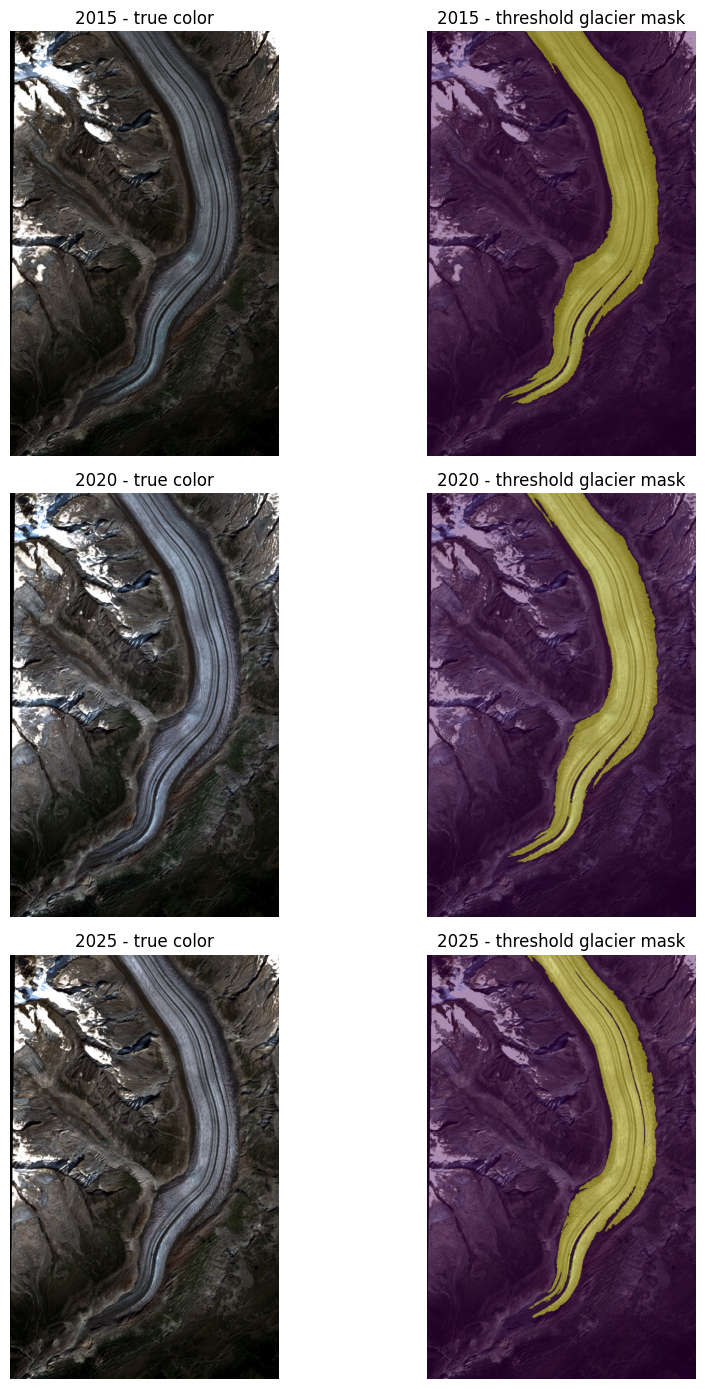

In [40]:
fig, axes = plt.subplots(len(YEARS), 2, figsize=(10, 14))

for i, year in enumerate(YEARS):
    rgb = make_rgb(s2_data[year], ("B04", "B03", "B02"))
    mask = threshold_masks[year]

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"{year} - true color")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(rgb)
    axes[i, 1].imshow(mask, alpha=0.45)
    axes[i, 1].set_title(f"{year} - threshold glacier mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_threshold_masks.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Method II: K-means segmentation

The second method is a comparison method. K-means groups pixels using selected bands and indices. After clustering, clusters are selected when they overlap with the threshold mask or have spectral values typical for snow and clean ice.

This method is not used as the final measurement, but it helps to compare, how another method behaves on the same data.

In [41]:
def kmeans_glacier_mask(data, ndsi, ndvi, reference_mask, n_clusters=5, random_state=42):
    features = np.dstack([
        percentile_stretch(data["B02"]),
        percentile_stretch(data["B03"]),
        percentile_stretch(data["B04"]),
        percentile_stretch(data["B08"]),
        percentile_stretch(data["B11"]),
        percentile_stretch(data["B12"]),
        percentile_stretch(ndsi, 1, 99),
        percentile_stretch(ndvi, 1, 99),
    ])

    h, w, c = features.shape
    X = features.reshape(-1, c)

    valid = np.all(np.isfinite(X), axis=1)
    X_valid = X[valid]

    rng = np.random.default_rng(random_state)
    sample_size = min(80000, len(X_valid))
    sample_idx = rng.choice(len(X_valid), size=sample_size, replace=False)

    model = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, batch_size=4096, n_init="auto")
    model.fit(X_valid[sample_idx])

    labels_flat = np.full(X.shape[0], -1, dtype=np.int32)
    labels_flat[valid] = model.predict(X_valid)
    labels = labels_flat.reshape(h, w)

    glacier_clusters = []


    for k in range(n_clusters):
        cluster_pixels = labels == k

        if np.any(cluster_pixels):
            mean_ndsi = np.nanmean(ndsi[cluster_pixels])
            mean_ndvi = np.nanmean(ndvi[cluster_pixels])
            mean_swir = np.nanmean(data["B11"][cluster_pixels])
            overlap = np.sum(cluster_pixels & reference_mask) / max(np.sum(cluster_pixels), 1)

            print(f"cluster {k}: mean NDSI={mean_ndsi:.3f}, mean NDVI={mean_ndvi:.3f}, mean B11={mean_swir:.1f}, overlap={overlap:.3f}")

            if overlap > 0.35 or (mean_ndsi > 0.45 and mean_ndvi < NDVI_MAX):
                glacier_clusters.append(k)


    mask = np.isin(labels, glacier_clusters)
    mask = mask | reference_mask
    mask = clean_mask(mask, min_size=MIN_OBJECT_SIZE, keep_largest=KEEP_LARGEST_COMPONENT)

    return mask, labels


kmeans_masks = {}
kmeans_labels = {}

for year in YEARS:
    print(f"\n{year}")

    mask, labels = kmeans_glacier_mask(
        s2_data[year],
        indices[year]["NDSI"],
        indices[year]["NDVI"],
        threshold_masks[year],
        n_clusters=5,
        random_state=year
    )

    kmeans_masks[year] = mask
    kmeans_labels[year] = labels

    save_mask(mask, ref_profile, RASTER_DIR / f"glacier_mask_kmeans_{year}.tif")
    print("glacier pixels:", int(mask.sum()))


2015
cluster 0: mean NDSI=0.834, mean NDVI=-0.138, mean B11=1317.4, overlap=0.741
cluster 1: mean NDSI=-0.285, mean NDVI=0.109, mean B11=20415.5, overlap=0.000
cluster 2: mean NDSI=0.903, mean NDVI=-0.077, mean B11=2350.0, overlap=0.000
cluster 3: mean NDSI=-0.516, mean NDVI=0.604, mean B11=15966.8, overlap=0.000
cluster 4: mean NDSI=-0.061, mean NDVI=-0.008, mean B11=8475.8, overlap=0.077
glacier pixels: 114049

2020
cluster 0: mean NDSI=-0.500, mean NDVI=0.598, mean B11=15911.3, overlap=0.000
cluster 1: mean NDSI=0.843, mean NDVI=-0.095, mean B11=1401.9, overlap=0.759
cluster 2: mean NDSI=-0.267, mean NDVI=0.105, mean B11=20550.8, overlap=0.000
cluster 3: mean NDSI=-0.016, mean NDVI=-0.001, mean B11=7757.7, overlap=0.145
cluster 4: mean NDSI=0.818, mean NDVI=-0.044, mean B11=4004.8, overlap=0.005
glacier pixels: 108119

2025
cluster 0: mean NDSI=-0.243, mean NDVI=0.063, mean B11=14062.3, overlap=0.001
cluster 1: mean NDSI=0.713, mean NDVI=-0.086, mean B11=1871.7, overlap=0.699
clust

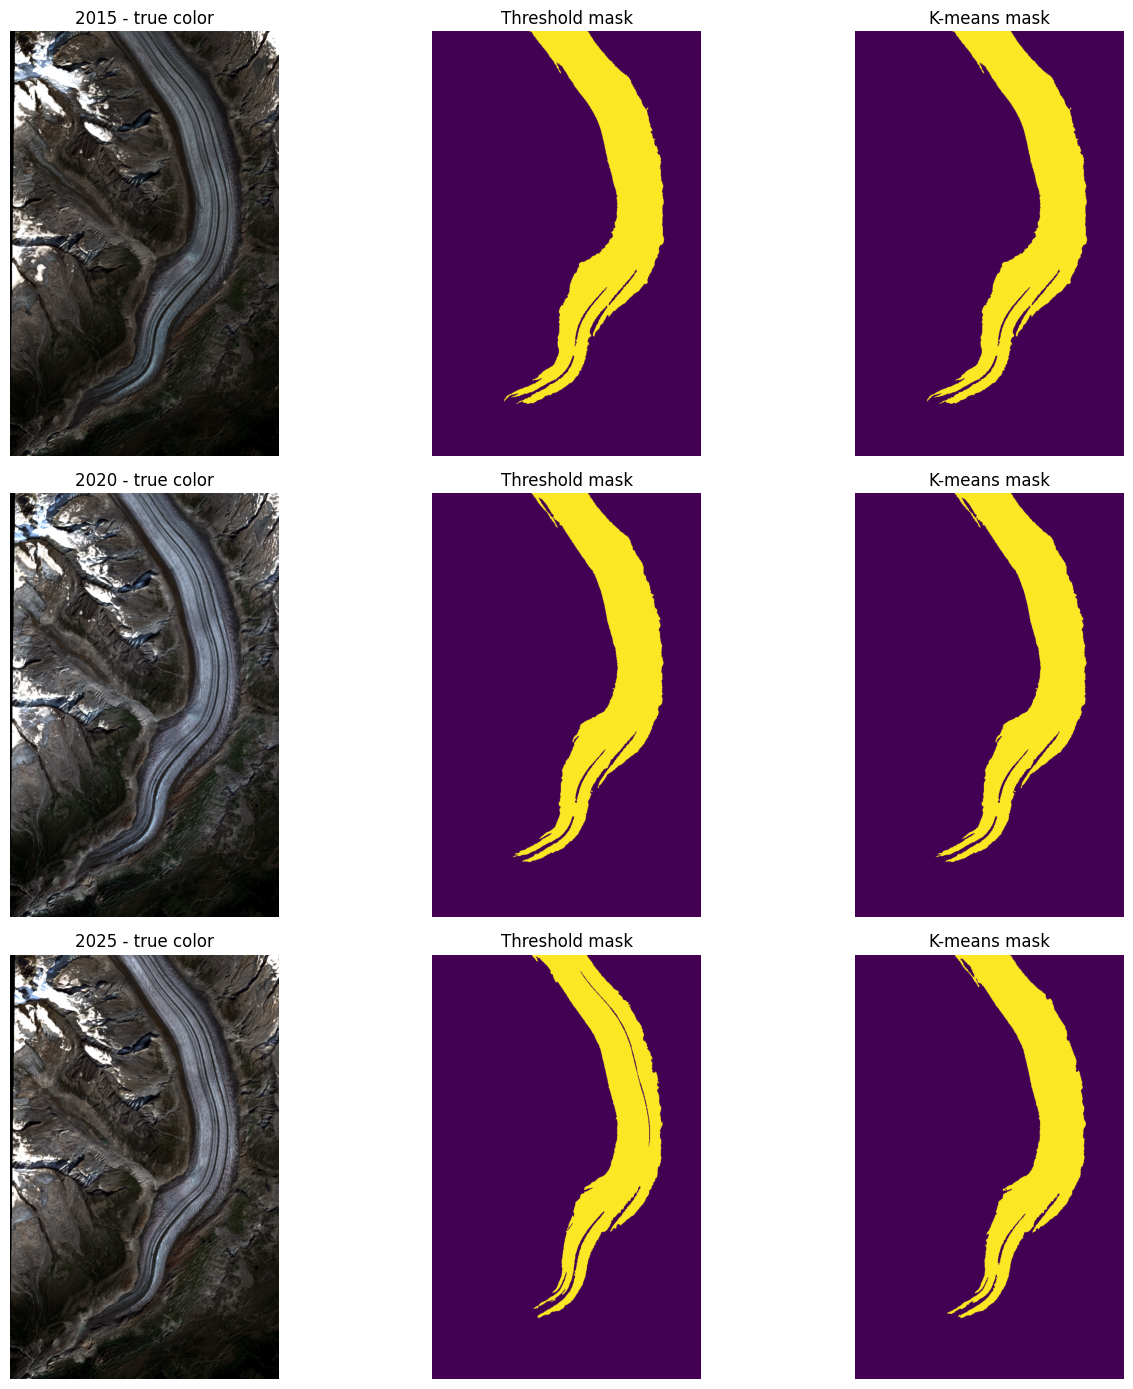

In [42]:
fig, axes = plt.subplots(len(YEARS), 3, figsize=(14, 14))

for i, year in enumerate(YEARS):
    rgb = make_rgb(s2_data[year], ("B04", "B03", "B02"))

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"{year} - true color")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(threshold_masks[year])
    axes[i, 1].set_title("Threshold mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(kmeans_masks[year])
    axes[i, 2].set_title("K-means mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_method_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Surface area calculation

Glacier area is calculated by multiplying the number of glacier pixels by the pixel area.

```text
area = number of glacier pixels * pixel area
```

For the Sentinel-2 10 m grid, one pixel is about 100 m2.

In [43]:
def area_from_mask(mask, pixel_area):
    area_m2 = np.sum(mask) * pixel_area

    return area_m2, area_m2 / 1e6

rows = []

for year in YEARS:
    for method_name, masks in [
        ("Threshold", threshold_masks),
        ("K-means", kmeans_masks),
    ]:
        area_m2, area_km2 = area_from_mask(masks[year], ref_pixel_area)
        rows.append({
            "Year": year,
            "Method": method_name,
            "Area [m2]": area_m2,
            "Area [km2]": area_km2,
            "Pixels": int(np.sum(masks[year]))
        })

area_df = pd.DataFrame(rows)
area_df

,Year,Method,Area [m2],Area [km2],Pixels
0,2015,Threshold,1.140860e+07,11.408601,114049
1,2015,K-means,1.140860e+07,11.408601,114049
2,2020,Threshold,1.081541e+07,10.815409,108119
3,2020,K-means,1.081541e+07,10.815409,108119
4,2025,Threshold,9.705749e+06,9.705749,97026
5,2025,K-means,1.018490e+07,10.184904,101816


In [44]:
area_pivot = area_df.pivot(index="Year", columns="Method", values="Area [km2]")
area_pivot["Threshold change from 2015 [km2]"] = area_pivot["Threshold"] - area_pivot.loc[2015, "Threshold"]
area_pivot["K-means change from 2015 [km2]"] = area_pivot["K-means"] - area_pivot.loc[2015, "K-means"]
area_pivot

Method,K-means,Threshold,Threshold change from 2015 [km2],K-means change from 2015 [km2]
Year,,,,
2015,11.408601,11.408601,0.000000,0.000000
2020,10.815409,10.815409,-0.593192,-0.593192
2025,10.184904,9.705749,-1.702852,-1.223697


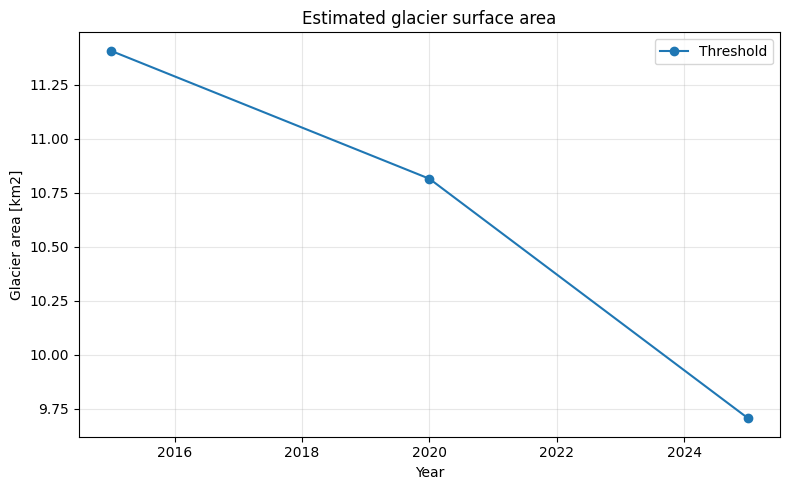

In [45]:
plt.figure(figsize=(8, 5))
subset = area_df[area_df["Method"] == "Threshold"]
plt.plot(subset["Year"], subset["Area [km2]"], marker="o", label="Threshold")

plt.xlabel("Year")
plt.ylabel("Glacier area [km2]")
plt.title("Estimated glacier surface area")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_area_change_plot.png", dpi=200, bbox_inches="tight")
plt.show()

In [46]:
threshold_range = np.arange(0.15, 0.41, 0.025)
sensitivity_rows = []

for year in YEARS:
    ndsi = indices[year]["NDSI"]
    ndvi = indices[year]["NDVI"]
    green = s2_data[year]["B03"]

    for threshold in threshold_range:
        raw_mask = (ndsi > threshold) & (ndvi < NDVI_MAX) & (green > 1000)
        mask = clean_mask(raw_mask, min_size=MIN_OBJECT_SIZE, keep_largest=KEEP_LARGEST_COMPONENT)

        area_m2, area_km2 = area_from_mask(mask, ref_pixel_area)

        sensitivity_rows.append({
            "Year": year,
            "NDSI threshold": round(float(threshold), 3),
            "Area [km2]": area_km2,
            "Pixels": int(mask.sum())
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,Year,NDSI threshold,Area [km2],Pixels
0,2015,0.150,11.704197,117004
1,2015,0.175,11.608966,116052
2,2015,0.200,11.539044,115353
3,2015,0.225,11.475423,114717
4,2015,0.250,11.408701,114050
5,2015,0.275,11.248950,112453
6,2015,0.300,11.135813,111322
7,2015,0.325,11.054186,110506
8,2015,0.350,10.924444,109209
9,2015,0.375,10.844218,108407


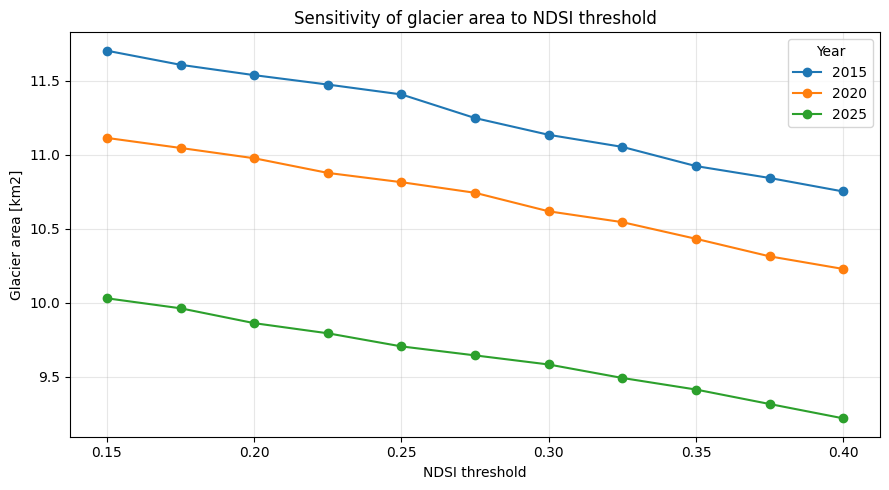

In [47]:
plt.figure(figsize=(9, 5))

for year in YEARS:
    subset = sensitivity_df[sensitivity_df["Year"] == year]
    plt.plot(
        subset["NDSI threshold"],
        subset["Area [km2]"],
        marker="o",
        label=str(year)
    )

plt.xlabel("NDSI threshold")
plt.ylabel("Glacier area [km2]")
plt.title("Sensitivity of glacier area to NDSI threshold")
plt.grid(True, alpha=0.3)
plt.legend(title="Year")
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Spatial change map: 2015 vs 2025

This map compares the threshold-based masks from 2015 and 2025.

- stable glacier area: detected in both of the years
- lost area: detected in 2015 but not in 2025
- gained or temporary area: detected in 2025 but not in 2015

The gained class can include seasonal snow or differences caused by image conditions, so the lost area is the more important part for glacier retreat.

In [48]:
mask_2015 = threshold_masks[2015]
mask_2025 = threshold_masks[2025]

stable = mask_2015 & mask_2025
lost = mask_2015 & ~mask_2025
gained = ~mask_2015 & mask_2025

change_map = np.zeros(ref_shape, dtype=np.uint8)
change_map[stable] = 1
change_map[lost] = 2
change_map[gained] = 3

save_mask(stable, ref_profile, RASTER_DIR / "stable_glacier_2015_2025.tif")
save_mask(lost, ref_profile, RASTER_DIR / "lost_glacier_2015_2025.tif")
save_mask(gained, ref_profile, RASTER_DIR / "gained_glacier_2015_2025.tif")

lost_area_m2, lost_area_km2 = area_from_mask(lost, ref_pixel_area)
gained_area_m2, gained_area_km2 = area_from_mask(gained, ref_pixel_area)
stable_area_m2, stable_area_km2 = area_from_mask(stable, ref_pixel_area)

print("Stable area [km2]:", stable_area_km2)
print("Lost area [km2]:", lost_area_km2)
print("Gained area [km2]:", gained_area_km2)

Stable area [km2]: 9.670337457708856
Lost area [km2]: 1.738263964773738
Gained area [km2]: 0.03541148895263298


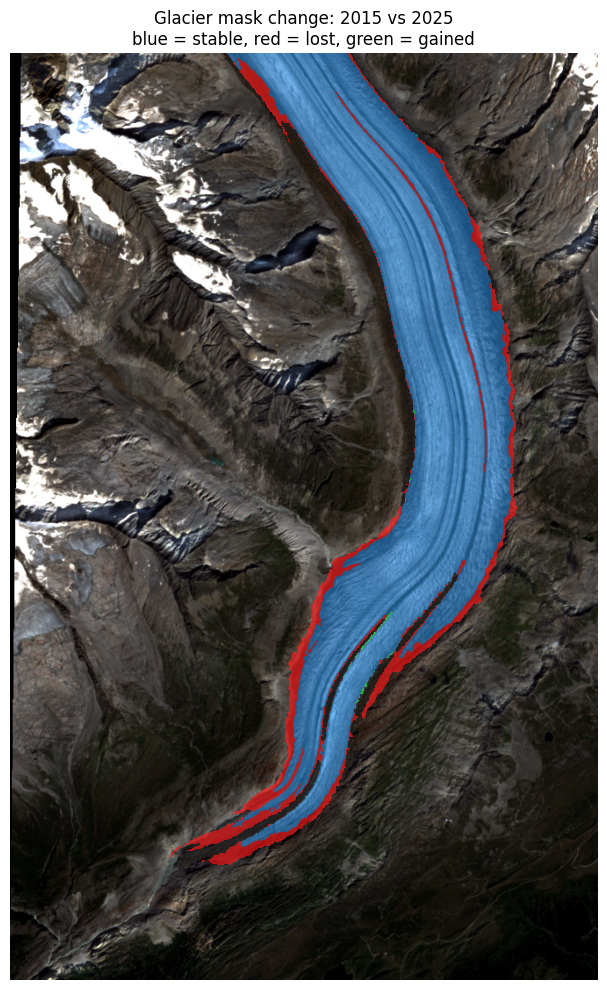

In [49]:
from matplotlib.colors import ListedColormap, BoundaryNorm

rgb_2025 = make_rgb(s2_data[2025], ("B04", "B03", "B02"))


overlay = np.full((*change_map.shape, 4), np.nan)

overlay[stable] = [0.1, 0.6, 1.0, 0.45]
overlay[lost] = [1.0, 0.1, 0.1, 0.65]
overlay[gained] = [0.1, 1.0, 0.2, 0.65]

plt.figure(figsize=(8, 10))
plt.imshow(rgb_2025)
plt.imshow(overlay)
plt.title("Glacier mask change: 2015 vs 2025\nblue = stable, red = lost, green = gained")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_change_map_2015_2025.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. DEM-derived elevation and volume change: 2015-2020

The file `N46E008_2015-01-01_2020-01-01_dhdt.tif` contains DEM-derived elevation change rate for the 2015-2020 period.

```text
dH = dhdt * 5
```

The volume change is then calculated over the glacier mask:

```text
volume change = sum(dH * pixel area)
```

The `dhdt` raster is reprojected to the Sentinel-2 grid and clipped with the 2015 threshold mask. This keeps the volume estimate consistent with the surface-area segmentation.

In [50]:
dhdt_path = DEM_PATH
print("Using dhdt file:", dhdt_path)

Using dhdt file: c:\Users\patry\OneDrive\Pulpit\UNI\sem4\ImageProcessing\project\data\DEM\N46E008_2015-01-01_2020-01-01_dhdt.tif


In [51]:
with rasterio.open(dhdt_path) as src:
    print("DEM/dhdt CRS:", src.crs)
    print("DEM/dhdt shape:", src.shape)

    print("DEM/dhdt transform:")
    print(src.transform)

    print("DEM/dhdt nodata:", src.nodata)
    print("DEM/dhdt bounds:", src.bounds)

    dhdt_on_s2 = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=dhdt_on_s2,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )

years_dem = 5
dh_2015_2020 = dhdt_on_s2 * years_dem
dh_2015_2020[~np.isfinite(dh_2015_2020)] = np.nan

save_float_raster(dhdt_on_s2, ref_profile, RASTER_DIR / "dhdt_2015_2020_on_sentinel_grid.tif")
save_float_raster(dh_2015_2020, ref_profile, RASTER_DIR / "dh_2015_2020_on_sentinel_grid.tif")

print("dhdt percentiles [m/year]:", np.nanpercentile(dhdt_on_s2, [1, 5, 50, 95, 99]))
print("dh total percentiles [m]:", np.nanpercentile(dh_2015_2020, [1, 5, 50, 95, 99]))

DEM/dhdt CRS: EPSG:32632
DEM/dhdt shape: (1122, 781)
DEM/dhdt transform:
| 100.00, 0.00, 422250.00|
| 0.00,-100.00, 5205850.00|
| 0.00, 0.00, 1.00|
DEM/dhdt nodata: -9999.0
DEM/dhdt bounds: BoundingBox(left=422250.0, bottom=5093650.0, right=500350.0, top=5205850.0)
dhdt percentiles [m/year]: [-6.12159673 -4.20423183 -0.03285386  0.01204748  0.20500458]
dh total percentiles [m]: [-30.60798353 -21.02115917  -0.16426929   0.0602374    1.02502289]


In [52]:
volume_mask = threshold_masks[2015]
dh_glacier = np.where(volume_mask, dh_2015_2020, np.nan)

mean_dh = np.nanmean(dh_glacier)
median_dh = np.nanmedian(dh_glacier)
min_dh = np.nanmin(dh_glacier)
max_dh = np.nanmax(dh_glacier)

volume_change_m3 = np.nansum(dh_glacier * ref_pixel_area)
volume_change_km3 = volume_change_m3 / 1e9

glacier_area_m2, glacier_area_km2 = area_from_mask(volume_mask, ref_pixel_area)

print("Glacier mask used for volume: threshold mask 2015")
print("Glacier area [km2]:", glacier_area_km2)
print("Mean elevation change 2015-2020 [m]:", mean_dh)
print("Median elevation change 2015-2020 [m]:", median_dh)
print("Min elevation change 2015-2020 [m]:", min_dh)
print("Max elevation change 2015-2020 [m]:", max_dh)
print("Volume change 2015-2020 [m3]:", volume_change_m3)
print("Volume change 2015-2020 [km3]:", volume_change_km3)

volume_results = pd.DataFrame([{
    "Period": "2015-2020",
    "Mask": "Threshold 2015",
    "Area [km2]": glacier_area_km2,
    "Mean dh [m]": mean_dh,
    "Median dh [m]": median_dh,
    "Volume change [m3]": volume_change_m3,
    "Volume change [km3]": volume_change_km3,
}])

volume_results

Glacier mask used for volume: threshold mask 2015
Glacier area [km2]: 11.408601422482594
Mean elevation change 2015-2020 [m]: -17.761494
Median elevation change 2015-2020 [m]: -17.044401
Min elevation change 2015-2020 [m]: -43.78264
Max elevation change 2015-2020 [m]: 9.044503
Volume change 2015-2020 [m3]: -2.026338e+08
Volume change 2015-2020 [km3]: -0.2026338


,Period,Mask,Area [km2],Mean dh [m],Median dh [m],Volume change [m3],Volume change [km3]
0,2015-2020,Threshold 2015,11.408601,-17.761494,-17.044401,-202633792.0,-0.202634


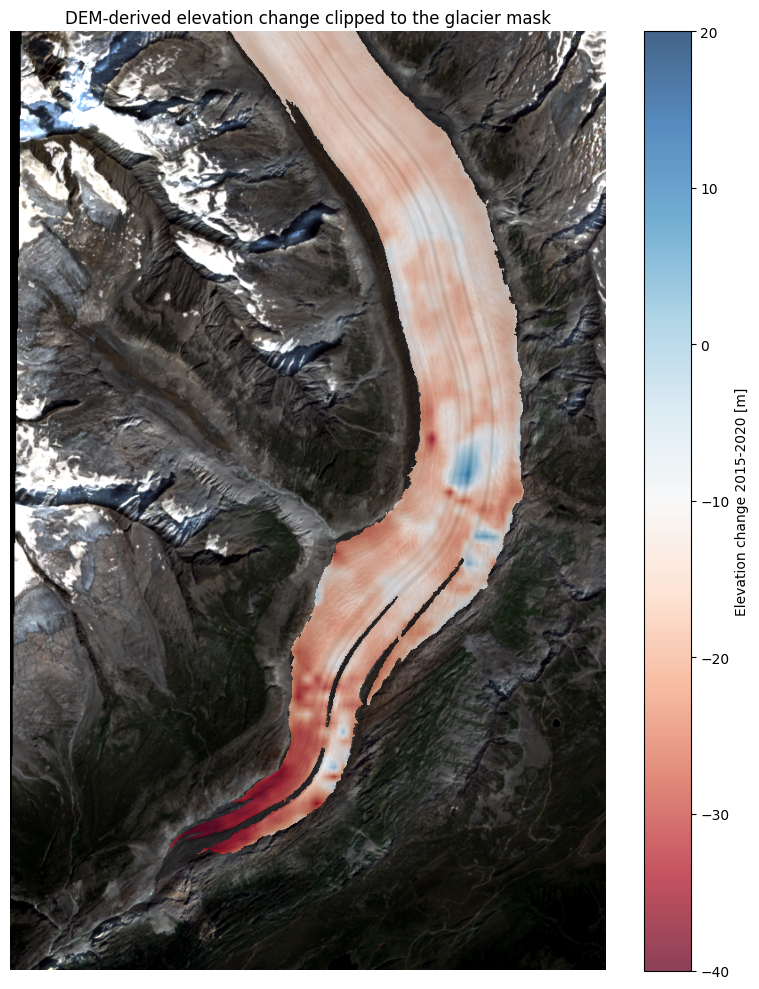

In [53]:
rgb_2020 = make_rgb(s2_data[2020], ("B04", "B03", "B02"))

plt.figure(figsize=(8, 10))
plt.imshow(rgb_2020)
im = plt.imshow(np.where(volume_mask, dh_2015_2020, np.nan), cmap="RdBu", vmin=-40, vmax=20, alpha=0.75)
plt.colorbar(im, label="Elevation change 2015-2020 [m]")
plt.title("DEM-derived elevation change clipped to the glacier mask")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_dem_elevation_change_on_glacier.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Exporting summary tables

In [54]:
area_df.to_csv(OUTPUT_DIR / "glacier_area_results.csv", index=False)
area_pivot.to_csv(OUTPUT_DIR / "glacier_area_pivot.csv")
volume_results.to_csv(OUTPUT_DIR / "glacier_volume_results.csv", index=False)

## 13. Conclusions

The lower tongue of the Great Aletsch Glacier was analyzed using Sentinel-2 images from 2015, 2020 and 2025. The glacier surface was segmented using NDSI-based thresholding and compared with a K-means result.

The threshold method is the main method used for area calculation because it is simple, stable and easy to interpret. K-means was treated as an additional comparison method. The estimated glacier area was calculated in square kilometers for every date, and the 2015-2025 change map shows stable, lost and gained or temporary snow/ice areas.

The DEM-derived `dhdt` raster for 2015-2020 was used to estimate elevation change over the selected glacier mask. Volume change was calculated by multiplying elevation change by pixel area and summing the result over the glacier pixels.

The main limitations of this approach are seasonal snow, ice with debris and shadows.